# The baseline ladder

Before any LLM, establish what cheap models achieve. Every rung uses the same `Report`, so the
fine-tuned model later is directly comparable.

Rungs: always-guess-the-average, metadata-only linear regression, TF-IDF + Ridge, and LSA + random
forest.

In [1]:
from pricer.baselines import constant, lsa_forest, metadata_only, tfidf
from pricer.evaluator import evaluate, leaderboard
from pricer.items import Wine

train, val, test = Wine.load_local()
print(f"train={len(train):,} val={len(val):,} test={len(test):,}")

train=82,786 val=2,000 test=2,000


### Rung 0: the geometric mean

Any model that cannot beat this is broken. Note the negative R2 -- squared error in dollars is
dominated by the expensive tail, which is exactly why RMSLE is the metric to watch.

Constant $30:   0%|          | 0/250 [00:00<?, ?it/s]

Constant $30: MAE $19.99 | RMSLE 0.670 | R2 -3.2% | hits 35.2%


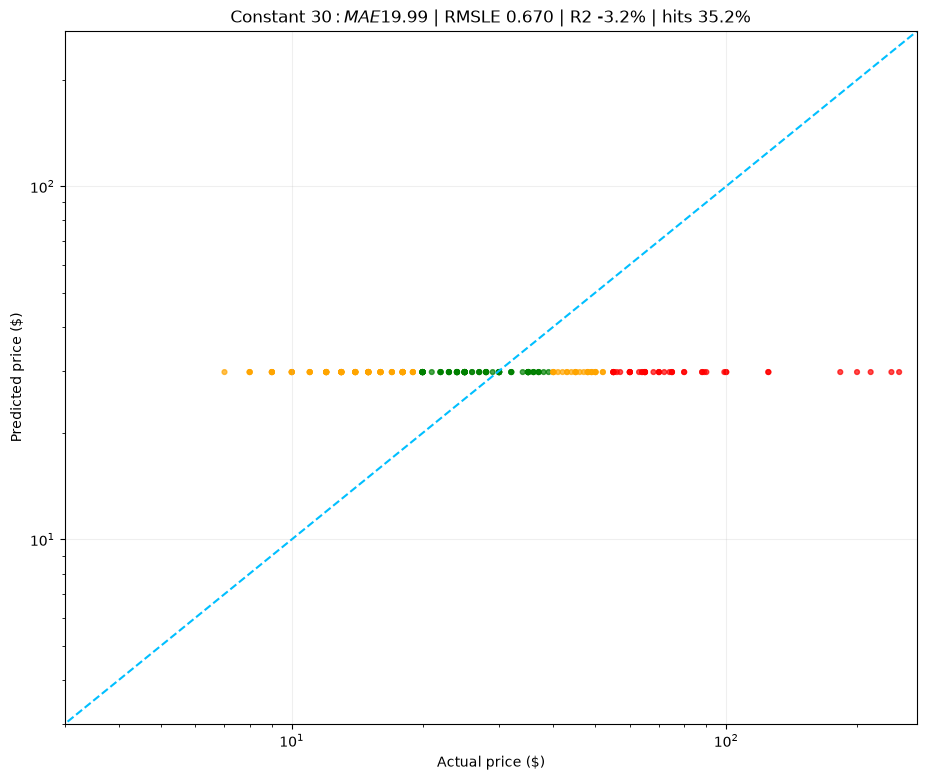

In [2]:
evaluate(constant(train), test)

### Rung 1: metadata only, no tasting note

Country, province, variety, vintage, note length.

Metadata + Linear Regression:   0%|          | 0/250 [00:00<?, ?it/s]

Metadata + Linear Regression: MAE $14.84 | RMSLE 0.483 | R2 33.8% | hits 58.8%


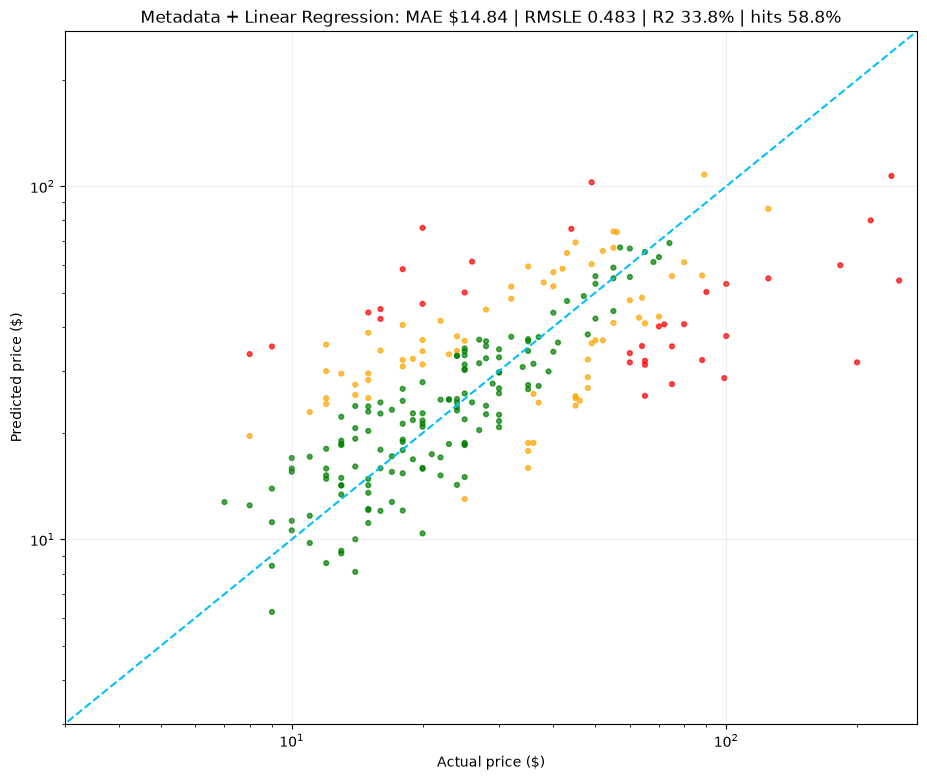

In [3]:
evaluate(metadata_only(train), test)

### Rung 2: the tasting note as bag-of-words

Tf-Idf + Ridge:   0%|          | 0/250 [00:00<?, ?it/s]

Tf-Idf + Ridge: MAE $12.80 | RMSLE 0.415 | R2 57.9% | hits 62.4%


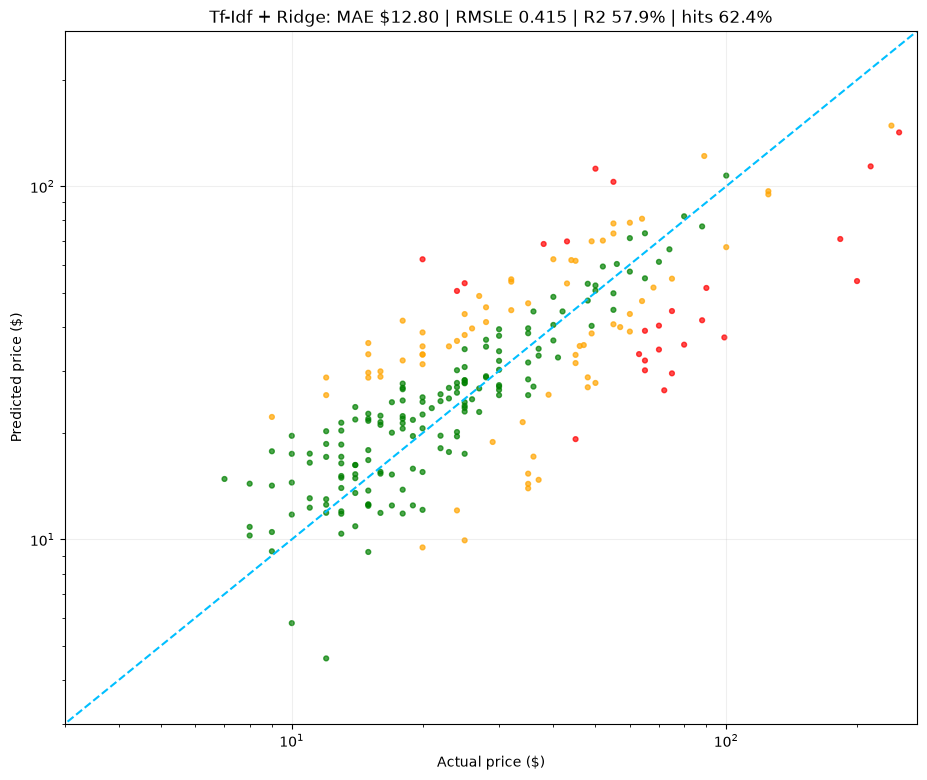

In [4]:
evaluate(tfidf(train), test)

### Rung 3: dense text features into a random forest

Lsa + Random Forest:   0%|          | 0/250 [00:00<?, ?it/s]

Lsa + Random Forest: MAE $13.50 | RMSLE 0.445 | R2 39.7% | hits 60.4%


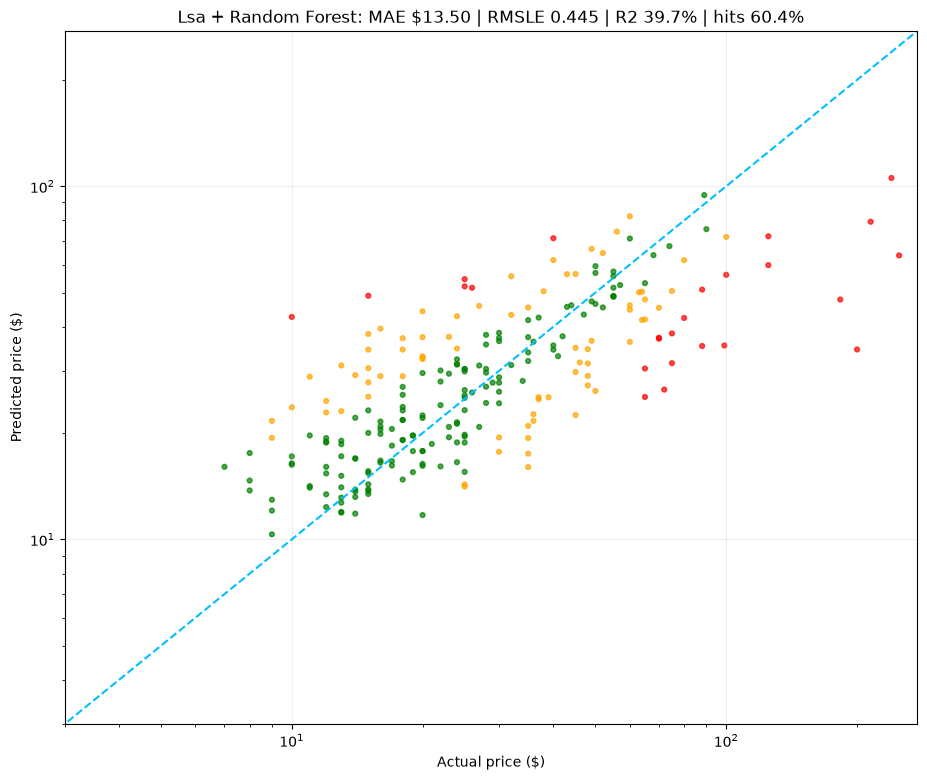

In [5]:
evaluate(lsa_forest(train), test)

In [6]:
leaderboard()

model                                    MAE    RMSLE      R2    hits      n
Tf-Idf + Ridge                        12.80    0.415   57.9%   62.4%    250
TF-IDF + Ridge                        12.82    0.423   38.3%   63.6%  2,000
Lsa + Random Forest                   13.50    0.445   39.7%   60.4%    250
Classical (note only)                 14.40    0.454   56.1%   57.0%    100
LSA + Random Forest                   13.42    0.454   31.9%   60.0%  2,000
Metadata + Linear Regression          14.84    0.483   33.8%   58.8%    250
Neighbours (k=8, retrieval only)      17.55    0.588   17.9%   53.0%    100
Constant $30                          19.99    0.670   -3.2%   35.2%    250


### Which words cost money?

Ridge coefficients on the word features, which double as a sanity check that the model is reading
tasting vocabulary rather than picking up on a scrape artefact.

In [7]:
import numpy as np

model = tfidf(train)
pipeline = model.pipeline
features = pipeline.named_steps["features"]
names = features.get_feature_names_out()
weights = pipeline.named_steps["model"].coef_
order = np.argsort(weights)
print("cheap:")
for index in order[:15]:
    print(f"  {names[index].split('__')[-1]:<24}{weights[index]:+.3f}")
print("expensive:")
for index in order[-15:][::-1]:
    print(f"  {names[index].split('__')[-1]:<24}{weights[index]:+.3f}")

cheap:
  value                   -2.806
  price                   -1.987
  inexpensive             -1.881
  bargain                 -1.666
  affordable              -1.590
  best buy                -1.522
  buy                     -1.507
  chianti                 -1.324
  ripasso                 -1.267
  kabinett                -1.213
  values                  -1.210
  000 cases               -1.167
  priced                  -1.162
  lodi                    -1.161
  more expensive          -1.148
expensive:
  gaja                    +2.113
  tba                     +1.773
  rancio                  +1.555
  2030                    +1.535
  amarone                 +1.522
  from 2012               +1.481
  2026                    +1.455
  condrieu                +1.449
  eiswein                 +1.427
  2025                    +1.386
  barrel sample           +1.369
  2022                    +1.369
  cases made              +1.333
  priorat                 +1.324
  2024                   

### Experiments worth running here

- Re-curate with `cap=20_000` and see whether the extra cheap wines help or just re-teach the prior.
- Add `points` to the composed text (`pricer.parser.compose`) and measure the jump. That gap is the
  value of the critic score, and a lower bound on how much a model can learn from the note alone.
- Predict `points` instead of price -- same harness, a much less skewed target.
- Swap Ridge for gradient boosting on the LSA features.